## Task 1 - Steady 1000 readings

1. Write a program that measures the magnetic field intensity in all three directions (𝐵𝑥,𝐵𝑦, 𝐵𝑧
)
every 100 ms and prints the value on the serial interface.

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Change filename if needed
filename = "Data_2/Task1_M2.txt"

df = pd.read_csv(
    filename,
    header=None,
    names=["Bx_raw", "By_raw", "Bz_raw"],
    skipinitialspace=True
)
df = df.iloc[:1000].reset_index(drop=True)

df.head()


,timestamp_ms,Bx_raw,By_raw,Bz_raw
0,2032,-1517,860,-385
1,2132,-1505,860,-385
2,2233,-1505,860,-378
3,2333,-1499,878,-385
4,2433,-1505,860,-385


In [75]:
df["Bx_raw"] = pd.to_numeric(df["Bx_raw"], errors="coerce")
df["By_raw"] = pd.to_numeric(df["By_raw"], errors="coerce")
df["Bz_raw"] = pd.to_numeric(df["Bz_raw"], errors="coerce")


df["Bx_uT"] = df["Bx_raw"] / 16.0
df["By_uT"] = df["By_raw"] / 16.0
df["Bz_uT"] = df["Bz_raw"] / 16.0
df.head()


,timestamp_ms,Bx_raw,By_raw,Bz_raw,Bx_uT,By_uT,Bz_uT
0,2032,-1517,860,-385,-94.8125,53.750,-24.0625
1,2132,-1505,860,-385,-94.0625,53.750,-24.0625
2,2233,-1505,860,-378,-94.0625,53.750,-23.6250
3,2333,-1499,878,-385,-93.6875,54.875,-24.0625
4,2433,-1505,860,-385,-94.0625,53.750,-24.0625


In [76]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update(mpl.rcParamsDefault)
plt.close("all")


a. Ensure steady conditions for your sensor and record 1,000 magnetic field readings.
Can you observe any drift? Repeat the measurements to ensure representative
conditions.

In [77]:
Bx_mean = df["Bx_uT"].mean()
By_mean = df["By_uT"].mean()
Bz_mean = df["Bz_uT"].mean()

print("Mean magnetic field values (µT)")
print(f"Bx̄ = {Bx_mean:.2f}")
print(f"Bȳ = {By_mean:.2f}")
print(f"Bz̄ = {Bz_mean:.2f}")


Mean magnetic field values (µT)
Bx̄ = -94.46
Bȳ = 54.20
Bz̄ = -23.79


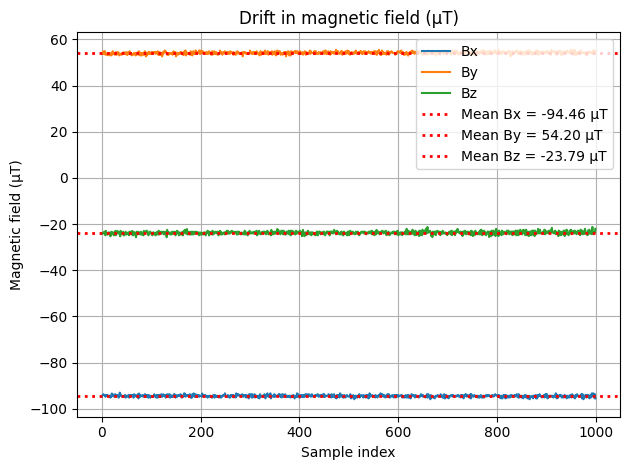

In [78]:
x = range(len(df))  # sample index

plt.figure()

plt.plot(x, df["Bx_uT"], label="Bx")
plt.plot(x, df["By_uT"], label="By")
plt.plot(x, df["Bz_uT"], label="Bz")


plt.axhline(
    df["Bx_uT"].mean(),
    linestyle=":",
    linewidth=2,
    color="red",
    label=f"Mean Bx = {df['Bx_uT'].mean():.2f} µT"
)

plt.axhline(
    df["By_uT"].mean(),
    linestyle=":",
    linewidth=2,
    color="red",
    label=f"Mean By = {df['By_uT'].mean():.2f} µT"
)

plt.axhline(
    df["Bz_uT"].mean(),
    linestyle=":",
    linewidth=2,
    color="red",
    label=f"Mean Bz = {df['Bz_uT'].mean():.2f} µT"
)


plt.title("Drift in magnetic field (µT)")
plt.xlabel("Sample index")
plt.ylabel("Magnetic field (µT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


b. Calculate for each direction the mean value 𝐵̅ and show your data with subtracted
mean value 𝐵 − 𝐵̅ in an appropriate histogram. How are the values distributed? Are
all three directions behaving the same? Do you observe any difference between
the FlipCore elements and the Hall sensor?Calculate for each direction the mean value 𝐵̅ and show your data with subtracted
mean value 𝐵 − 𝐵̅ in an appropriate histogram. How are the values distributed? Are
all three directions behaving the same? Do you observe any difference between
the FlipCore elements and the Hall sensor?

In [79]:
Bx_mean = df["Bx_uT"].mean()
By_mean = df["By_uT"].mean()
Bz_mean = df["Bz_uT"].mean()

print("Mean magnetic field values (µT)")
print(f"Bx̄ = {Bx_mean:.2f}")
print(f"Bȳ = {By_mean:.2f}")
print(f"Bz̄ = {Bz_mean:.2f}")




Mean magnetic field values (µT)
Bx̄ = -94.46
Bȳ = 54.20
Bz̄ = -23.79


In [80]:
df["Bx_dev"] = df["Bx_uT"] - Bx_mean
df["By_dev"] = df["By_uT"] - By_mean
df["Bz_dev"] = df["Bz_uT"] - Bz_mean

Bx_std = df["Bx_dev"].std(ddof=1)
By_std = df["By_dev"].std(ddof=1)
Bz_std = df["Bz_dev"].std(ddof=1)

print("Standard deviation (µT)")
print(f"σ_Bx = {Bx_std:.3f}")
print(f"σ_By = {By_std:.3f}")
print(f"σ_Bz = {Bz_std:.3f}")


Standard deviation (µT)
σ_Bx = 0.472
σ_By = 0.518
σ_Bz = 0.633


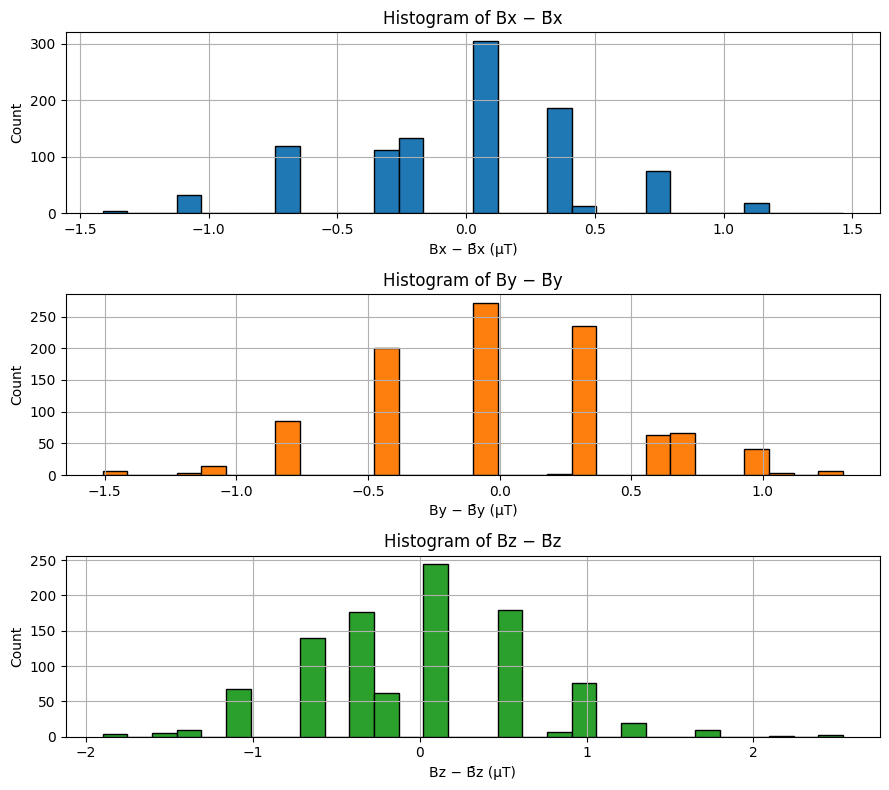

In [82]:
plt.figure(figsize=(9,8))

# Bx histogram (C0)
plt.subplot(3,1,1)
plt.hist(df["Bx_dev"], bins=30, color="C0", edgecolor="black")
plt.title("Histogram of Bx − B̄x")
plt.xlabel("Bx − B̄x (µT)")
plt.ylabel("Count")
plt.grid(True)

# By histogram (C1)
plt.subplot(3,1,2)
plt.hist(df["By_dev"], bins=30, color="C1", edgecolor="black")
plt.title("Histogram of By − B̄y")
plt.xlabel("By − B̄y (µT)")
plt.ylabel("Count")
plt.grid(True)

# Bz histogram (C2)
plt.subplot(3,1,3)
plt.hist(df["Bz_dev"], bins=30, color="C2", edgecolor="black")
plt.title("Histogram of Bz − B̄z")
plt.xlabel("Bz − B̄z (µT)")
plt.ylabel("Count")
plt.grid(True)

plt.tight_layout()
plt.show()


## Task 2 - 180 degree flip

In [56]:
#File Processing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0 = pd.read_csv("Data_2/Task2_Steady_M2.txt")
df_x = pd.read_csv("Data_2/Task2_XFlip_M2.txt")
df_y = pd.read_csv("Data_2/Task2_YFlip_M2.txt")

for df in [df_0, df_x, df_y]:
    df.columns = df.columns.str.strip()


#Numeric data and conversion to microtesla

for df in [df_0, df_x, df_y]:
    df["Bx_raw"] = pd.to_numeric(df["Bx_raw"], errors="coerce")
    df["By_raw"] = pd.to_numeric(df["By_raw"], errors="coerce")
    df["Bz_raw"] = pd.to_numeric(df["Bz_raw"], errors="coerce")

    df["Bx_uT"] = df["Bx_raw"] / 16.0
    df["By_uT"] = df["By_raw"] / 16.0
    df["Bz_uT"] = df["Bz_raw"] / 16.0


df_0.head()


,Timestamp_ms,Bx_raw,By_raw,Bz_raw,Bx_uT,By_uT,Bz_uT
0,2036,-459,1092,-452,-28.6875,68.2500,-28.2500
1,2136,-459,1103,-452,-28.6875,68.9375,-28.2500
2,2236,-448,1074,-446,-28.0000,67.1250,-27.8750
3,2337,-442,1092,-459,-27.6250,68.2500,-28.6875
4,2437,-448,1104,-440,-28.0000,69.0000,-27.5000


a. Ensure steady conditions for your sensor and record 100 magnetic field readings.
Take the mean value in each direction.

In [57]:
# Mean in each orientation

mean_0 = df_0[["Bx_uT", "By_uT", "Bz_uT"]].mean()
mean_x = df_x[["Bx_uT", "By_uT", "Bz_uT"]].mean()
mean_y = df_y[["Bx_uT", "By_uT", "Bz_uT"]].mean()

print("Normal orientation:")
print(mean_0, "\n")

print("180° rotation around x-axis:")
print(mean_x, "\n")

print("180° rotation around y-axis:")
print(mean_y)


Normal orientation:
Bx_uT   -28.083333
By_uT    68.451389
Bz_uT   -27.861742
dtype: float64 

180° rotation around x-axis:
Bx_uT   -30.075758
By_uT    27.658460
Bz_uT    65.530303
dtype: float64 

180° rotation around y-axis:
Bx_uT   -65.666667
By_uT    68.316288
Bz_uT    65.940025
dtype: float64


b. Flip your board 180° around the x-axis and repeat the measurement for offset correction. Then, flip your board 180° around the y-axis and repeat the measurement.
Ensure that the board’s positioning does not change or that no external factors
affect the magnetic field

c. Compare your results from 2a and 2b for each direction. What is the sensor’s offset? Does this match the range specified in the datasheet? Are all three directions
behaving the same? Do you observe any difference between the FlipCore elements
and the Hall sensor?

In [58]:
# Offset calculation

offset_x = (mean_0["Bx_uT"] + mean_y["Bx_uT"]) / 2
offset_y = (mean_0["By_uT"] + mean_x["By_uT"]) / 2
offset_z = (mean_0["Bz_uT"] + mean_x["Bz_uT"]) / 2

print(f"Offset X = {offset_x:.2f} µT")
print(f"Offset Y = {offset_y:.2f} µT")
print(f"Offset Z = {offset_z:.2f} µT")


Offset X = -46.88 µT
Offset Y = 48.05 µT
Offset Z = 18.83 µT


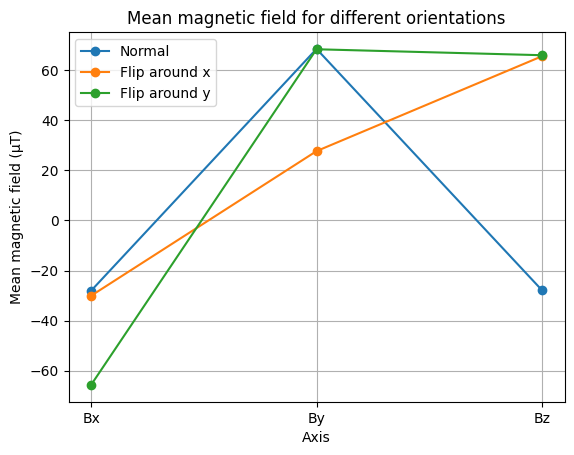

In [59]:
labels = ["Bx", "By", "Bz"]
x = range(len(labels))

plt.figure()

plt.plot(x, mean_0.values, marker="o", label="Normal")
plt.plot(x, mean_x.values, marker="o", label="Flip around x")
plt.plot(x, mean_y.values, marker="o", label="Flip around y")

plt.xticks(x, labels)
plt.xlabel("Axis")
plt.ylabel("Mean magnetic field (µT)")
plt.title("Mean magnetic field for different orientations")
plt.grid(True)
plt.legend()
plt.show()


## Task-3

1. Use your program from the first task to measure the earth's magnetic field at your place.
In your evaluation, consider the offsets obtained in task 2.
<br>
a. Find a place outdoor where you can perform an undisturbed measurement. Avoid
metals that might influence the magnetic field locally. For each direction, use the
mean value of the acquired data and report it together with the standard deviation
(e.g., (42 ± 3) µT)

In [ ]:
# Replace with your actual outdoor filename
filename = "Data_2/Task3_outdoor.txt"

df_outdoor = pd.read_csv(
    filename,
    header=None,
    names=["timestamp_ms", "Bx_raw", "By_raw", "Bz_raw"],
    skipinitialspace=True
)

# Use only the first 1000 samples
df_outdoor = df_outdoor.iloc[:1000].reset_index(drop=True)


In [ ]:
# Convert raw data to numeric
df_outdoor["Bx_raw"] = pd.to_numeric(df_outdoor["Bx_raw"], errors="coerce")
df_outdoor["By_raw"] = pd.to_numeric(df_outdoor["By_raw"], errors="coerce")
df_outdoor["Bz_raw"] = pd.to_numeric(df_outdoor["Bz_raw"], errors="coerce")

# Convert to microtesla
df_outdoor["Bx_uT"] = df_outdoor["Bx_raw"] / 16.0
df_outdoor["By_uT"] = df_outdoor["By_raw"] / 16.0
df_outdoor["Bz_uT"] = df_outdoor["Bz_raw"] / 16.0


In [ ]:
# Subtract the offsets
df_outdoor["Bx_corr"] = df_outdoor["Bx_uT"] - offset_x
df_outdoor["By_corr"] = df_outdoor["By_uT"] - offset_y
df_outdoor["Bz_corr"] = df_outdoor["Bz_uT"] - offset_z


In [ ]:
# Compute mean and standard deviation for corrected values
means = df_outdoor[["Bx_corr", "By_corr", "Bz_corr"]].mean()
stds  = df_outdoor[["Bx_corr", "By_corr", "Bz_corr"]].std(ddof=1)

# Display results
print("Outdoor corrected field (mean ± std) in µT")
for ax in ["Bx_corr", "By_corr", "Bz_corr"]:
    print(f"{ax}: {means[ax]:.2f} ± {stds[ax]:.2f}")


In [ ]:
# Sample index for x-axis
x = range(len(df_outdoor))

# Plot corrected magnetic field components
plt.figure()
plt.plot(x, df_outdoor["Bx_corr"], label="Bx")
plt.plot(x, df_outdoor["By_corr"], label="By")
plt.plot(x, df_outdoor["Bz_corr"], label="Bz")
plt.title("Outdoor corrected magnetic field")
plt.xlabel("Sample index")
plt.ylabel("Magnetic field (µT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Task-4

In [ ]:
# Sample index for x-axis
x = range(len(df_outdoor))

# Plot corrected magnetic field components
plt.figure()
plt.plot(x, df_outdoor["Bx_corr"], label="Bx")
plt.plot(x, df_outdoor["By_corr"], label="By")
plt.plot(x, df_outdoor["Bz_corr"], label="Bz")
plt.title("Outdoor corrected magnetic field")
plt.xlabel("Sample index")
plt.ylabel("Magnetic field (µT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Task-5

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the outdoor measurement file
# Replace with the actual filename for your outdoor measurement
filename = "Data_2/Task5_outdoor.txt"

df_outdoor = pd.read_csv(
    filename,
    header=None,
    names=["timestamp_ms", "Bx_raw", "By_raw", "Bz_raw"],
    skipinitialspace=True
)

# Use only the first 1000 samples
df_outdoor = df_outdoor.iloc[:1000].reset_index(drop=True)

# Step 2: Convert raw values to microtesla
for c in ["Bx_raw", "By_raw", "Bz_raw"]:
    df_outdoor[c] = pd.to_numeric(df_outdoor[c], errors="coerce")

df_outdoor["Bx_uT"] = df_outdoor["Bx_raw"] / 16.0
df_outdoor["By_uT"] = df_outdoor["By_raw"] / 16.0
df_outdoor["Bz_uT"] = df_outdoor["Bz_raw"] / 16.0

# Step 3: Apply the offsets from Task 2
# Offsets obtained from Task 2 (replace with your actual calculated values)

# Apply the offsets to the magnetic field data
df_outdoor["Bx_corr"] = df_outdoor["Bx_uT"] - offset_x
df_outdoor["By_corr"] = df_outdoor["By_uT"] - offset_y
df_outdoor["Bz_corr"] = df_outdoor["Bz_uT"] - offset_z

# Step 4: Calculate the Heading Angle
# Use the arctangent function to compute the heading (angle) in radians
df_outdoor["heading_rad"] = np.arctan2(df_outdoor["By_corr"], df_outdoor["Bx_corr"])

# Convert the heading from radians to degrees
df_outdoor["heading_deg"] = np.degrees(df_outdoor["heading_rad"])

# Normalize the heading to a range of 0° to 360°
df_outdoor["heading_deg"] = (df_outdoor["heading_deg"] + 360) % 360

# Step 5: Visualize the Heading Over Time
# Sample index for the x-axis
x = range(len(df_outdoor))

# Plot heading angle over time
plt.figure()
plt.plot(x, df_outdoor["heading_deg"], label="Heading (degrees)")
plt.title("Compass Heading Over Time")
plt.xlabel("Sample index")
plt.ylabel("Heading (degrees)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
